In [98]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [99]:
df = pd.read_csv('placement.csv')

In [100]:
df

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No
...,...,...,...,...,...,...,...,...,...,...
9995,CLG0021,119,8.41,8.29,4,No,1,8,0,Yes
9996,CLG0098,70,9.25,9.34,7,No,0,7,2,No
9997,CLG0066,89,6.08,6.25,3,Yes,3,9,5,No
9998,CLG0045,107,8.77,8.92,3,No,7,5,1,No


In [101]:
df.shape

(10000, 10)

In [102]:
df['Placement'].value_counts()

Placement
No     8341
Yes    1659
Name: count, dtype: int64

In [103]:
(df['Placement'].value_counts(normalize=True))*100

Placement
No     83.41
Yes    16.59
Name: proportion, dtype: float64

In [104]:
df[df['Placement']=='Yes']['CGPA'].mean()

np.float64(8.592483423749247)

In [105]:
df[df['Placement']=='No']['CGPA'].mean()

np.float64(7.321527394796787)

In [106]:
pd.crosstab(df['Internship_Experience'],df['Placement'])

Placement,No,Yes
Internship_Experience,,
No,5024,1012
Yes,3317,647


In [107]:
df.groupby('Placement')['Projects_Completed'].mean()

Placement
No     2.346961
Yes    3.350211
Name: Projects_Completed, dtype: float64

In [108]:
df.groupby('Placement')['IQ'].mean()

Placement
No      97.552452
Yes    109.121760
Name: IQ, dtype: float64

In [109]:
df.groupby('Placement')['Prev_Sem_Result'].mean()

Placement
No     7.330462
Yes    8.567420
Name: Prev_Sem_Result, dtype: float64

In [110]:
df.groupby('Placement')['Academic_Performance'].mean()

Placement
No     5.565520
Yes    5.450271
Name: Academic_Performance, dtype: float64

In [111]:
pd.crosstab(df['Internship_Experience'],df['Placement'])

Placement,No,Yes
Internship_Experience,,
No,5024,1012
Yes,3317,647


In [112]:
df.groupby('Placement')['Communication_Skills'].mean()

Placement
No     5.143748
Yes    7.663653
Name: Communication_Skills, dtype: float64

In [113]:
df.groupby('Placement')['Projects_Completed'].mean()

Placement
No     2.346961
Yes    3.350211
Name: Projects_Completed, dtype: float64

In [114]:
df.groupby('Placement')['Extra_Curricular_Score'].mean()

Placement
No     4.977581
Yes    4.937312
Name: Extra_Curricular_Score, dtype: float64

In [115]:
df.corr(numeric_only=True)

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
IQ,1.000000,-0.002640,-0.002859,-0.006827,-0.003458,-0.010896,0.014538
Prev_Sem_Result,-0.002640,1.000000,0.980768,-0.005765,0.009326,-0.017269,0.018434
CGPA,-0.002859,0.980768,1.000000,-0.002958,0.011441,-0.018242,0.020872
Academic_Performance,-0.006827,-0.005765,-0.002958,1.000000,0.011774,-0.019733,-0.013148
Extra_Curricular_Score,-0.003458,0.009326,0.011441,0.011774,1.000000,0.003769,0.008122
Communication_Skills,-0.010896,-0.017269,-0.018242,-0.019733,0.003769,1.000000,-0.004486
Projects_Completed,0.014538,0.018434,0.020872,-0.013148,0.008122,-0.004486,1.000000


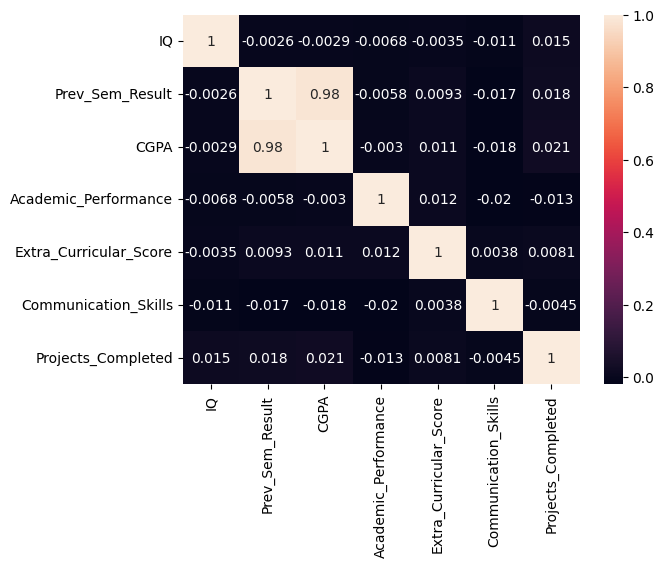

In [116]:

sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [117]:
df.sort_values(by='CGPA',ascending=False).head(10)

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
5999,CLG0076,82,9.99,10.46,1,No,6,7,1,No
4004,CLG0027,79,10.00,10.46,1,Yes,1,9,5,Yes
9769,CLG0065,73,9.98,10.45,6,No,2,8,1,No
2277,CLG0072,82,9.99,10.45,4,Yes,7,4,0,No
8418,CLG0010,91,9.97,10.44,7,No,1,3,5,No
5813,CLG0089,87,9.95,10.42,10,No,5,6,3,No
2081,CLG0054,109,9.96,10.42,10,No,3,4,0,No
8164,CLG0059,73,9.95,10.41,1,Yes,2,7,4,No
8374,CLG0067,97,9.93,10.40,3,No,10,6,5,No
4699,CLG0044,92,9.96,10.40,3,No,5,4,1,No


In [118]:
pd.pivot_table(
    df,
    values = 'Projects_Completed',
    index='Internship_Experience',
    columns='Placement',
    aggfunc='mean'
)

Placement,No,Yes
Internship_Experience,,
No,2.354299,3.388340
Yes,2.335846,3.290572


In [119]:
df['Placement'] = df['Placement'].map({'Yes':1,'No':0})

In [120]:
df['Internship_Experience'] = df['Internship_Experience'].map({'Yes':1,'No':0})

In [121]:
X = df.drop(['Placement','College_ID'],axis=1)
Y = df['Placement']

## Train Test Split

## f

In [225]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

In [226]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    shuffle=False   # 👈 IMPORTANT
)

In [4]:
# Install (agar zarurat ho)
# pip install imbalanced-learn

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load dataset
df = pd.read_csv("placement.csv")

# Drop ID column
df = df.drop("College_ID", axis=1)

# Encode categorical columns
le_intern = LabelEncoder()
df["Internship_Experience"] = le_intern.fit_transform(df["Internship_Experience"])

le_target = LabelEncoder()
df["Placement"] = le_target.fit_transform(df["Placement"])
# No = 0 , Yes = 1

# Features and Target
X = df.drop("Placement", axis=1)
y = df["Placement"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check before SMOTE
print("Before SMOTE:")
print(y_train.value_counts())

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Check after SMOTE
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

# Train Model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

# Prediction
y_pred = rf.predict(X_test)

# Evaluation
print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Before SMOTE:
Placement
0    6673
1    1327
Name: count, dtype: int64

After SMOTE:
Placement
0    6673
1    6673
Name: count, dtype: int64

Accuracy:
0.999

Confusion Matrix:
[[1667    1]
 [   1  331]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1668
           1       1.00      1.00      1.00       332

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [9]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance
importance.to_csv("importance.csv")


In [3]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='f1'
)

print(scores)
print("Average F1:", scores.mean())

[0.99848714 0.9984917  1.         0.9984917  0.9984917 ]
Average F1: 0.9987924507636174


## model

## Prediction

## Accuracy

## F1 Score

In [11]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test,y_pred)
print("f1 Score",f1)

f1 Score 0.9969879518072289


## Confusion Matrix

## Classification Report

## Feature importance

In [163]:
print(Y.value_counts())

Placement
0    8341
1    1659
Name: count, dtype: int64


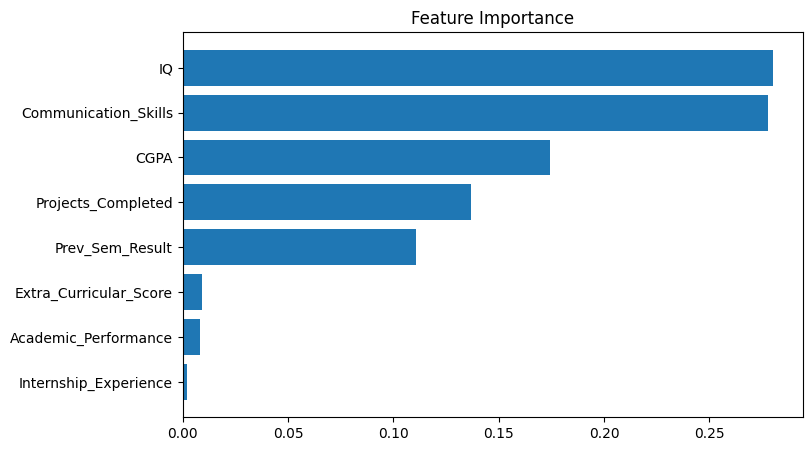

In [150]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(importance['Feature'], importance['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

In [152]:
print(df['Placement'].value_counts())

Placement
No     8341
Yes    1659
Name: count, dtype: int64


In [10]:
df.groupby('Placement')['CGPA'].mean()

Placement
0    7.321527
1    8.592483
Name: CGPA, dtype: float64

In [145]:
df.groupby('Placement')['Communication_Skills'].mean()

Placement
No     5.143748
Yes    7.663653
Name: Communication_Skills, dtype: float64

In [144]:
df.groupby('Placement')['Projects_Completed'].mean()

Placement
No     2.346961
Yes    3.350211
Name: Projects_Completed, dtype: float64

In [143]:
pd.crosstab(df['Internship_Experience'],df['Placement'])

Placement,No,Yes
Internship_Experience,,
No,5024,1012
Yes,3317,647


In [142]:
importance.sort_values(by='Importance',ascending=False).head(1)

,Feature,Importance
6,Communication_Skills,0.297839


In [141]:
df.sort_values(by='CGPA',ascending=False).head(10)

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
5999,CLG0076,82,9.99,10.46,1,No,6,7,1,No
4004,CLG0027,79,10.00,10.46,1,Yes,1,9,5,Yes
9769,CLG0065,73,9.98,10.45,6,No,2,8,1,No
2277,CLG0072,82,9.99,10.45,4,Yes,7,4,0,No
8418,CLG0010,91,9.97,10.44,7,No,1,3,5,No
5813,CLG0089,87,9.95,10.42,10,No,5,6,3,No
2081,CLG0054,109,9.96,10.42,10,No,3,4,0,No
8164,CLG0059,73,9.95,10.41,1,Yes,2,7,4,No
8374,CLG0067,97,9.93,10.40,3,No,10,6,5,No
4699,CLG0044,92,9.96,10.40,3,No,5,4,1,No


In [140]:
weak = df[(df['CGPA']<7)&(df['Communication_Skills']<5)]
weak.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
15,CLG0040,91,6.05,5.80,3,No,4,2,3,No
31,CLG0034,127,5.68,6.10,5,No,4,3,1,No
40,CLG0090,111,7.28,6.98,1,No,3,2,3,No
42,CLG0036,98,5.79,5.51,9,No,10,3,0,No


In [139]:
def suggest(cgpa,comm,proj,iq):

    suggestions=[]

    if cgpa<7.5:
        suggestions.append("Improve CGPA")

    if comm<7:
        suggestions.append("Improve Communication Skills")

    if proj<3:
        suggestions.append("Complete More Projects")

    if iq<80:
        suggestions.append("Practice Aptitude")

    return suggestions

In [138]:
student = X_test.iloc[[0]]
model.predict(student)
model.predict_proba(student)

array([[0.99, 0.01]])

In [137]:
import joblib
joblib.dump(model,'placement_model.pkl')

['placement_model.pkl']

In [136]:
print(df.dtypes)

College_ID                    str
IQ                          int64
Prev_Sem_Result           float64
CGPA                      float64
Academic_Performance        int64
Internship_Experience         str
Extra_Curricular_Score      int64
Communication_Skills        int64
Projects_Completed          int64
Placement                     str
dtype: object


In [135]:
df['CGPA'] = pd.to_numeric(df['CGPA'],errors='coerce')
df['Communication_Skills'] = pd.to_numeric(df['Communication_Skills'],errors='coerce')
df['Projects_Completed'] = pd.to_numeric(df['Projects_Completed'],errors='coerce')

In [134]:
import pandas as pd
df = pd.read_csv("placement.csv")
print(df.columns.tolist())

['College_ID', 'IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance', 'Internship_Experience', 'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed', 'Placement']
